# Free stimulation patterns in a low-dimensional space

**Goal.** Let the BO design an *arbitrary* temporal stimulation pattern — a
different **exposure time** per pulse — using only a handful of dials (so a GP
can search it), while the **total light budget stays fixed** (the question is
"*does the shape matter?*", holding dose constant).

We vary **exposure time per pulse** (LED power fixed). A pattern is a list of
exposure times `e_0 … e_{n-1}` (ms) with two hard rules: every `e_i >= 0` and
`sum_i e_i = B` (here 4000 ms, as in v13).

This notebook focuses on **option B — a polynomial shape with 3 coefficients**
(it subsumes the old "signed ramp", which is just its first coefficient), gives
an **interactive playground**, and works out **how to handle pulse interval**.
Three other parameterisations (Fourier, localized bumps, block-simplex) are kept
further down for comparison.

| | dials | what it gives |
|---|---|---|
| **B. Polynomial (focus)** | c1 tilt, c2 curvature, c3 cubic | ramp up/down, hump, plateau, asymmetry |
| C. Fourier / cosine | first few frequencies | periodic / multi-burst at fixed phases |
| D. Localized bumps | a few bumps | bursts placeable anywhere (more dials) |
| E. Block simplex | budget per chunk | blocky, ultra-interpretable |

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=1, suppress=True)

# Fixed total LED-on time per condition (ms) -- pinned, as in v13.
BUDGET_MS = 4000.0

# Stim window in frames (1 frame = 1 min), exactly as the v13 experiment.
FIRST_FRAME_STIM = 10
LAST_FRAME_STIM = 70


def pulse_positions(pulse_interval, first=FIRST_FRAME_STIM, last=LAST_FRAME_STIM):
    """Frame indices where pulses fire: range(first, last, pulse_interval)."""
    return np.arange(first, last, int(pulse_interval))


def normalized_time(n):
    """n pulse slots -> positions in [0, 1].

    Defining the shape on NORMALIZED time makes it independent of how many
    pulses there are: the same dials give a comparable shape whether n=6 or
    n=60.  That lets pulse spacing be a separate concern from pattern shape.
    """
    if n <= 1:
        return np.array([0.5])
    return np.linspace(0.0, 1.0, n)


def softmax_to_budget(logits, budget=BUDGET_MS):
    """Turn arbitrary real numbers ('logits') into per-pulse exposures that are
    (a) all >= 0 and (b) sum exactly to `budget`:

        e_i = budget * exp(logit_i) / sum_j exp(logit_j)

    exp(.) forces positivity; dividing by the sum forces the budget.  Also
    SHIFT-INVARIANT: adding a constant to every logit changes nothing -- which
    is why, with the budget fixed, we only parameterise *deviations from flat*
    (a constant 'level' dial would do nothing).
    """
    logits = np.asarray(logits, dtype=float)
    w = np.exp(logits - logits.max())
    return budget * w / w.sum()


def basis_poly(t, K=3):
    """Legendre polynomials P1..PK on [0,1] (constant P0 dropped).

    Column 1 = tilt (linear), 2 = curvature (quadratic), 3 = cubic (S/asymmetry).
    """
    x = 2 * t - 1
    P = [np.ones_like(x), x]
    for k in range(2, K + 1):
        P.append(((2 * k - 1) * x * P[k - 1] - (k - 1) * P[k - 2]) / k)
    return np.column_stack([P[k] for k in range(1, K + 1)])


def make_exposures(Phi, c, budget=BUDGET_MS):
    """Expand dials `c` into the full exposure list: softmax(Phi @ c) * budget."""
    return softmax_to_budget(np.asarray(Phi) @ np.asarray(c, float), budget)


# A representative grid for the static plots (pulse_interval = 5 -> 12 pulses).
n = 12
t = normalized_time(n)


## The one trick, checked

Every approach differs only in how it builds the `logits`; the
`softmax_to_budget` step is shared, so **whatever the BO proposes is always a
valid pattern** — non-negative and exactly on budget. No constraints to police
during acquisition.

In [2]:
rng = np.random.default_rng(0)
logits = rng.normal(size=12)
e = softmax_to_budget(logits)
print(f"all non-negative : {np.all(e >= 0)}")
print(f"sums to budget   : {e.sum():.3f} ms  (target {BUDGET_MS:.0f})")
print(f"shift-invariant  : {np.allclose(e, softmax_to_budget(logits + 100.0))}")


all non-negative : True
sums to budget   : 4000.000 ms  (target 4000)
shift-invariant  : True


## B — Polynomial shape with **3 coefficients**

`logit_i = c1·P1(t_i) + c2·P2(t_i) + c3·P3(t_i)`, then softmax to the budget.
Each coefficient is one interpretable knob:

| dial | polynomial | effect |
|---|---|---|
| **c1** | tilt (linear) | strong→weak (c1<0) vs weak→strong (c1>0). **This alone is the old "signed ramp" — option A is just B with c2=c3=0.** |
| **c2** | curvature (quadratic) | centre-loaded **hump / sustain** (c2<0) vs ends-loaded **U** (c2>0). Its *magnitude* sets peak width: small = broad plateau-ish, large = narrow spike. |
| **c3** | cubic | **asymmetry**: fast-up/slow-down vs slow-up/fast-down. |

Below: each dial swept on its own (other two = 0).

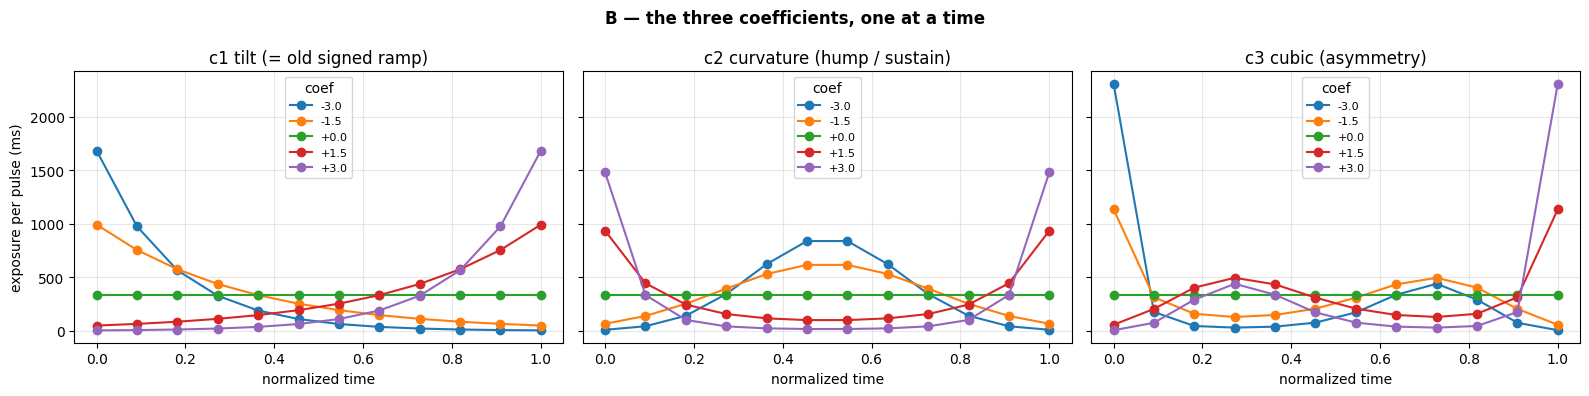

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
sweeps = [
    ("c1 tilt (= old signed ramp)", 0),
    ("c2 curvature (hump / sustain)", 1),
    ("c3 cubic (asymmetry)", 2),
]
for ax, (title, idx) in zip(axes, sweeps):
    for v in [-3, -1.5, 0, 1.5, 3]:
        c = [0.0, 0.0, 0.0]; c[idx] = v
        ax.plot(t, make_exposures(basis_poly(t, 3), c), "o-", label=f"{v:+.1f}")
    ax.set_title(title)
    ax.set_xlabel("normalized time")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, title="coef")
axes[0].set_ylabel("exposure per pulse (ms)")
fig.suptitle("B — the three coefficients, one at a time", fontweight="bold")
plt.tight_layout()
plt.show()


### B can do "ramp up → sustained → ramp down"

Fit a **trapezoid** (rise → flat hold → fall): K=2 gives a broad rounded
sustain; adding the even **quartic** (K=4) flattens it into a real plateau; the
odd **cubic** (c3) instead buys **asymmetry**, not flatness.

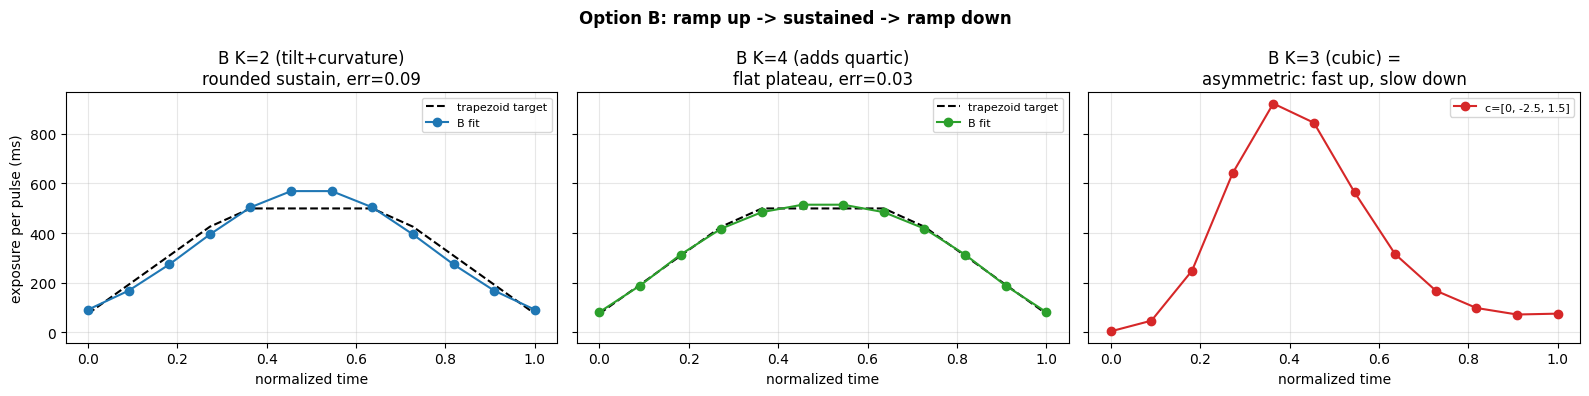

B K=2 rounded sustain err=0.09 | B K=4 flat plateau err=0.03


In [4]:
tB = normalized_time(12)
ramp = np.clip(np.minimum(tB / 0.33, (1 - tB) / 0.33), 0, 1)
trap = 0.15 + 0.85 * ramp
trap_ms = BUDGET_MS * trap / trap.sum()


def best_poly_fit(target, K):
    """Best (log-projection) polynomial fit at order K -> (exposures, error)."""
    Phi = basis_poly(normalized_time(len(target)), K)
    p = np.clip(target, 1e-9, None); p = p / p.sum()
    c, *_ = np.linalg.lstsq(Phi, np.log(p) - np.log(p).mean(), rcond=None)
    e = make_exposures(Phi, c)
    return e, np.abs(e - BUDGET_MS * p).sum() / BUDGET_MS


fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
e2, err2 = best_poly_fit(trap, 2)
axes[0].plot(tB, trap_ms, "k--", lw=1.5, label="trapezoid target")
axes[0].plot(tB, e2, "o-", color="tab:blue", label="B fit")
axes[0].set_title(f"B K=2 (tilt+curvature)\nrounded sustain, err={err2:.2f}")
e4, err4 = best_poly_fit(trap, 4)
axes[1].plot(tB, trap_ms, "k--", lw=1.5, label="trapezoid target")
axes[1].plot(tB, e4, "o-", color="tab:green", label="B fit")
axes[1].set_title(f"B K=4 (adds quartic)\nflat plateau, err={err4:.2f}")
e_asym = make_exposures(basis_poly(tB, 3), [0.0, -2.5, 1.5])
axes[2].plot(tB, e_asym, "o-", color="tab:red", label="c=[0, -2.5, 1.5]")
axes[2].set_title("B K=3 (cubic) =\nasymmetric: fast up, slow down")
for ax in axes:
    ax.set_xlabel("normalized time"); ax.grid(alpha=0.3); ax.legend(fontsize=8)
axes[0].set_ylabel("exposure per pulse (ms)")
fig.suptitle("Option B: ramp up -> sustained -> ramp down", fontweight="bold")
plt.tight_layout()
plt.show()
print(f"B K=2 rounded sustain err={err2:.2f} | B K=4 flat plateau err={err4:.2f}")


## Playground — freely play with the 3 coefficients

**Drag the sliders** (run this cell in Jupyter / VS Code). Left = the continuous
shape the coefficients define; right = the actual per-frame schedule the
microscope would deliver at the chosen `pulse_interval` (always summing to
4000 ms).

If sliders don't render in your viewer, just call
`show_pattern(c1, c2, c3, pulse_interval)` with numbers.

In [ ]:
def show_pattern(c1=0.0, c2=-2.0, c3=0.0, pulse_interval=5):
    coeffs = [c1, c2, c3]
    # continuous shape (relative), fine grid
    tf = np.linspace(0, 1, 200)
    shape = np.exp(basis_poly(tf, 3) @ np.array(coeffs))
    shape = shape / shape.max()
    # realized schedule at the chosen interval
    frames = pulse_positions(pulse_interval)
    expo = make_exposures(basis_poly(normalized_time(len(frames)), 3), coeffs)

    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    ax[0].plot(tf, shape, color="tab:blue")
    ax[0].fill_between(tf, shape, alpha=0.15)
    ax[0].set_title(f"shape  c = [{c1:.2f}, {c2:.2f}, {c3:.2f}]")
    ax[0].set_xlabel("normalized time"); ax[0].set_ylabel("relative exposure")
    ax[0].set_ylim(0, 1.05); ax[0].grid(alpha=0.3)

    ax[1].stem(frames, expo, basefmt=" ")
    ax[1].set_title(f"schedule: {len(frames)} pulses @ pi={pulse_interval} min  |  "
                    f"sum={expo.sum():.0f} ms, peak={expo.max():.0f} ms")
    ax[1].set_xlabel("frame (min)"); ax[1].set_ylabel("exposure (ms)")
    ax[1].set_xlim(FIRST_FRAME_STIM - 1, LAST_FRAME_STIM); ax[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()


try:
    from ipywidgets import interact, FloatSlider, IntSlider
    interact(
        show_pattern,
        c1=FloatSlider(value=0.0, min=-4, max=4, step=0.25, description="c1 tilt"),
        c2=FloatSlider(value=-2.0, min=-4, max=4, step=0.25, description="c2 curve"),
        c3=FloatSlider(value=0.0, min=-4, max=4, step=0.25, description="c3 cubic"),
        pulse_interval=IntSlider(value=5, min=1, max=20, step=1, description="pi (min)"),
    )
except Exception as exc:
    print("ipywidgets unavailable, static example:", exc)
    show_pattern()


interactive(children=(FloatSlider(value=0.0, description='c1 tilt', max=4.0, min=-4.0, step=0.25), FloatSlider…

## Pulse interval — how to implement it

The clean split this design buys you: **shape** (the 3 coeffs, on normalized
time) vs **timing** (`pulse_interval` = how many pulses, how far apart). Because
the shape lives on [0,1], the *same* coefficients give the *same* envelope
whether there are 6 pulses or 60 — `pulse_interval` just resamples it.

**Three ways to handle it:**

1. **Drop it — fixed dense grid.** Put a pulse on every frame and let the shape
   carry everything. Cleanest (no confound), but it cannot make *discrete,
   widely-spaced* pulses; many tiny pulses ≈ continuous low light.
2. **Keep it as a separate BO axis (recommended).** Shape = relative
   distribution of the fixed budget; `pulse_interval` = count/spacing. This is
   far more orthogonal than v13, where `ramp_fraction` *and* `pulse_interval`
   both moved per-pulse amplitude together.
3. **Anchor its range to the CRY2 ~5-min dark-reversion** (your lab's
   optoFGFR/optoEGFR constant): intervals **< 5 min** make pulses *summate* →
   sustained ERK; **> 5 min** give *discrete* ERK peaks. So `pulse_interval`
   becomes a real regime knob (sustained ↔ discrete), not just a dose dial.

**Residual caveat.** At fixed budget the mean per-pulse exposure is
`budget / n_pulses`, and `n_pulses` falls as the interval grows — so a larger
interval means fewer, *bigger* pulses. The shape normalization removes v13's
`ramp_fraction × interval` coupling, but per-pulse *amplitude* still tracks
`1/n`. That's acceptable here (the question is "distribution at fixed total
dose", and frequency genuinely changes the regime) — just don't read "best
pulse_interval" as pure frequency. If you need them fully separated, fix the
*per-pulse* dose and let the budget float (a different experiment).

**Recommendation:** keep `pulse_interval` as one BO axis, range anchored to CRY2
(e.g. 1–20 min, spanning summation→discrete), shape on normalized time.
**3 shape coeffs + pulse_interval = 4 control dims** — right at the ceiling your
FOV count supports.

The cell below shows one fixed shape realised at three intervals.

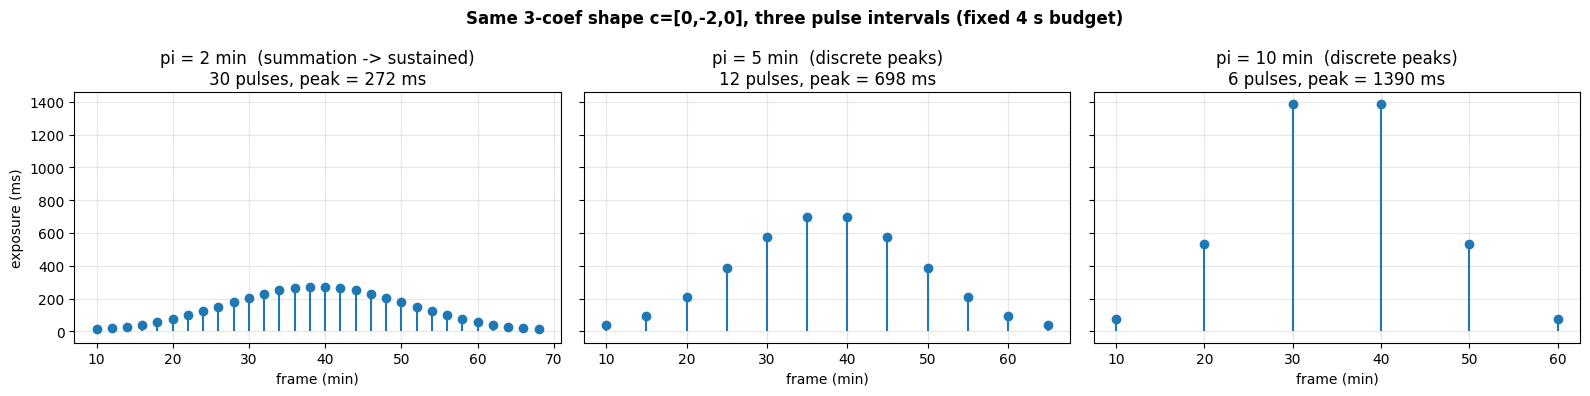

Same shape; spacing, pulse count and per-pulse dose change with interval.


In [6]:
shape_c = [0.0, -2.0, 0.0]      # symmetric up -> sustain -> down
CRY2_REVERSION_MIN = 5

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, pi in zip(axes, [2, 5, 10]):
    frames = pulse_positions(pi)
    expo = make_exposures(basis_poly(normalized_time(len(frames)), 3), shape_c)
    ax.stem(frames, expo, basefmt=" ")
    regime = "summation -> sustained" if pi < CRY2_REVERSION_MIN else "discrete peaks"
    ax.set_title(f"pi = {pi} min  ({regime})\n{len(frames)} pulses, "
                 f"peak = {expo.max():.0f} ms")
    ax.set_xlabel("frame (min)"); ax.grid(alpha=0.3)
axes[0].set_ylabel("exposure (ms)")
fig.suptitle("Same 3-coef shape c=[0,-2,0], three pulse intervals "
             "(fixed 4 s budget)", fontweight="bold")
plt.tight_layout()
plt.show()
print("Same shape; spacing, pulse count and per-pulse dose change with interval.")


## Other parameterisations (kept for comparison)

Below: **C Fourier/cosine**, **D localized bumps**, **E block-simplex** — the
alternatives B is being chosen over. The comparison cells at the end quantify
why.

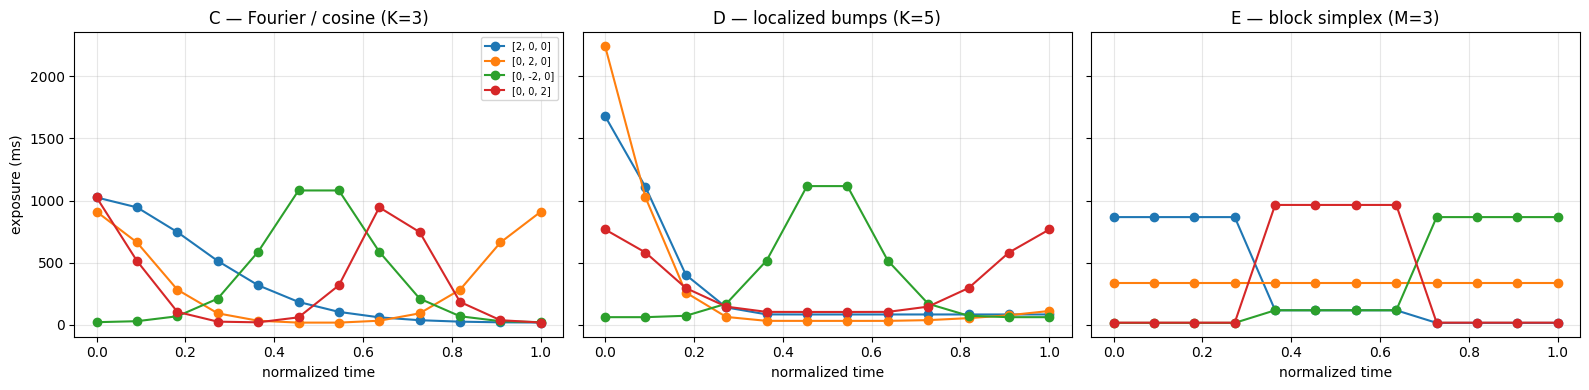

In [7]:
def basis_fourier(t, K=3):
    return np.column_stack([np.cos(k * np.pi * t) for k in range(1, K + 1)])


def basis_bumps(t, K=5, width=None):
    centers = np.linspace(0, 1, K)
    if width is None:
        width = 1.5 / max(K - 1, 1)
    cols = []
    for c in centers:
        d = np.abs(t - c) / width
        cols.append(np.where(d < 1, 0.5 * (1 + np.cos(np.pi * d)), 0.0))
    return np.column_stack(cols)


def basis_blocks(t, M=3):
    edges = np.linspace(0, 1, M + 1)
    cols = []
    for m in range(M):
        lo, hi = edges[m], edges[m + 1]
        inside = (t >= lo) & (t <= hi if m == M - 1 else t < hi)
        cols.append(inside.astype(float))
    return np.column_stack(cols)


fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for c in [[2, 0, 0], [0, 2, 0], [0, -2, 0], [0, 0, 2]]:
    axes[0].plot(t, make_exposures(basis_fourier(t, 3), c), "o-", label=f"{c}")
axes[0].set_title("C — Fourier / cosine (K=3)")
for c in [[3, 0, 0, 0, 0], [3, -1, -1, -1, 0], [0, 0, 3, 0, 0], [2, 0, 0, 0, 2]]:
    axes[1].plot(t, make_exposures(basis_bumps(t, 5), c), "o-")
axes[1].set_title("D — localized bumps (K=5)")
for c in [[2, 0, -2], [0, 0, 0], [-2, 0, 2], [-2, 2, -2]]:
    axes[2].plot(t, make_exposures(basis_blocks(t, 3), c), "o-")
axes[2].set_title("E — block simplex (M=3)")
for ax in axes:
    ax.set_xlabel("normalized time"); ax.grid(alpha=0.3)
axes[0].set_ylabel("exposure (ms)"); axes[0].legend(fontsize=7)
plt.tight_layout()
plt.show()


## Comparison 1 — expressiveness (which approach reproduces which shape?)

For each approach we project `log(target)` onto its basis (a fair, shared
proxy), rebuild the exposures, and score the mismatch
`error = sum_i |e_i − target_i| / budget` (0 = perfect).

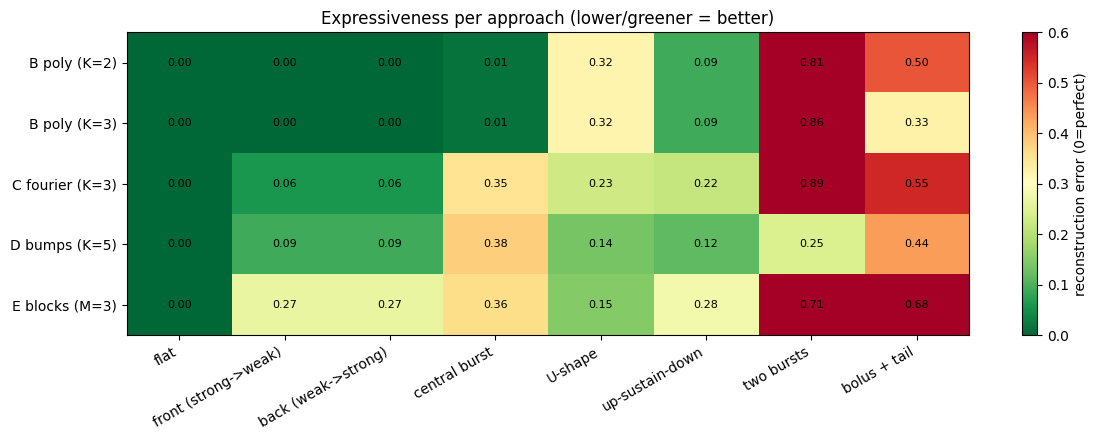

In [8]:
def fit_basis_to_target(Phi, target, budget=BUDGET_MS):
    p = np.clip(np.asarray(target, float), 1e-9, None); p = p / p.sum()
    log_p = np.log(p)
    c, *_ = np.linalg.lstsq(Phi, log_p - log_p.mean(), rcond=None)
    e = make_exposures(Phi, c, budget)
    return e, np.abs(e - budget * p).sum() / budget


def canonical_targets(nn):
    tt = normalized_time(nn)
    spike = np.zeros(nn); spike[0] = 1.0
    return {
        "flat":                 np.ones(nn),
        "front (strong->weak)": np.exp(-3 * tt),
        "back (weak->strong)":  np.exp(3 * tt),
        "central burst":        np.exp(-((tt - 0.5) ** 2) / (2 * 0.12 ** 2)),
        "U-shape":              1 - 0.9 * np.exp(-((tt - 0.5) ** 2) / (2 * 0.15 ** 2)),
        "up-sustain-down":      np.clip(np.minimum(tt / 0.33, (1 - tt) / 0.33), 0, 1) * 0.85 + 0.15,
        "two bursts":           (np.exp(-((tt - 0.2) ** 2) / (2 * 0.08 ** 2))
                                 + np.exp(-((tt - 0.75) ** 2) / (2 * 0.08 ** 2))),
        "bolus + tail":         spike + 0.12,
    }


def build_bases(nn):
    tt = normalized_time(nn)
    return {
        "B poly (K=2)":    basis_poly(tt, 2),
        "B poly (K=3)":    basis_poly(tt, 3),
        "C fourier (K=3)": basis_fourier(tt, 3),
        "D bumps (K=5)":   basis_bumps(tt, 5),
        "E blocks (M=3)":  basis_blocks(tt, 3),
    }


bases = build_bases(n)
targets = canonical_targets(n)
err = np.array([[fit_basis_to_target(Phi, tg)[1] for tg in targets.values()]
                for Phi in bases.values()])

fig, ax = plt.subplots(figsize=(12, 4.5))
im = ax.imshow(err, cmap="RdYlGn_r", vmin=0, vmax=0.6, aspect="auto")
ax.set_xticks(range(len(targets))); ax.set_xticklabels(targets.keys(), rotation=30, ha="right")
ax.set_yticks(range(len(bases))); ax.set_yticklabels(bases.keys())
for i in range(err.shape[0]):
    for j in range(err.shape[1]):
        ax.text(j, i, f"{err[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, label="reconstruction error (0=perfect)")
ax.set_title("Expressiveness per approach (lower/greener = better)")
plt.tight_layout()
plt.show()


## Comparison 2 — coverage & effective dimensionality

Sample random dials, generate envelopes, and count how many *independent* shape
directions actually emerge (SVD of the generated envelopes).

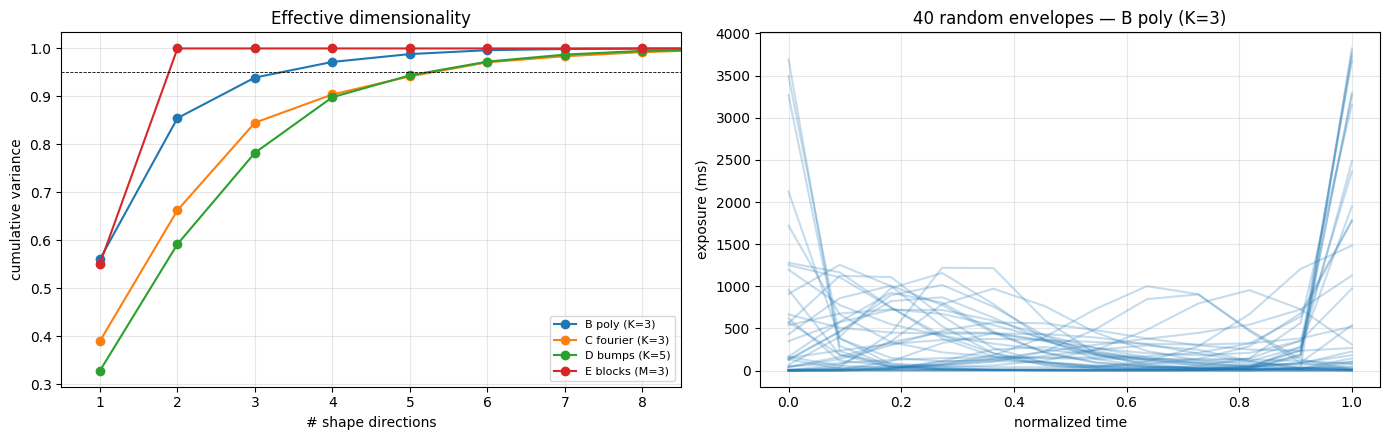

In [9]:
def sample_envelopes(Phi, n_samples=500, scale=2.0, seed=0):
    r = np.random.default_rng(seed)
    C = r.normal(0, scale, size=(n_samples, Phi.shape[1]))
    return np.array([make_exposures(Phi, c) for c in C])


fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for key in ["B poly (K=3)", "C fourier (K=3)", "D bumps (K=5)", "E blocks (M=3)"]:
    E = sample_envelopes(bases[key]); Ec = E - E.mean(0)
    s = np.linalg.svd(Ec, compute_uv=False) ** 2
    axes[0].plot(range(1, len(s) + 1), np.cumsum(s) / s.sum(), "o-", label=key)
axes[0].set_xlabel("# shape directions"); axes[0].set_ylabel("cumulative variance")
axes[0].set_title("Effective dimensionality"); axes[0].set_xlim(0.5, 8.5)
axes[0].axhline(0.95, color="k", ls="--", lw=0.6); axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)
for row in sample_envelopes(bases["B poly (K=3)"], n_samples=40):
    axes[1].plot(t, row, color="tab:blue", alpha=0.25)
axes[1].set_xlabel("normalized time"); axes[1].set_ylabel("exposure (ms)")
axes[1].set_title("40 random envelopes — B poly (K=3)"); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Comparison 3 — GP-friendliness (smoothness)

The dials become the GP's input axes, so dial→shape must be smooth. We step one
dial and measure how far the envelope moves.

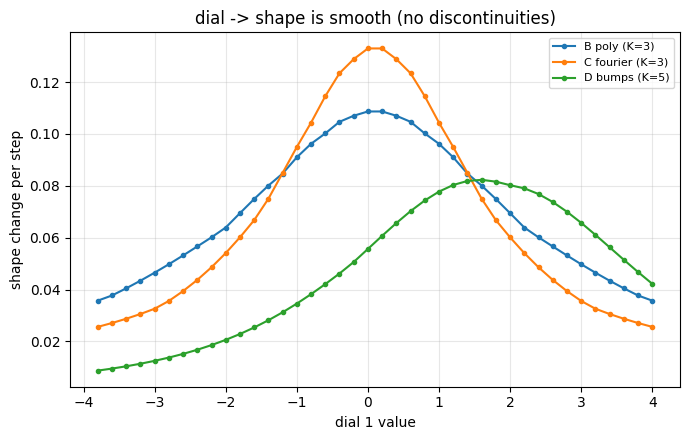

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for key in ["B poly (K=3)", "C fourier (K=3)", "D bumps (K=5)"]:
    Phi = bases[key]; base_c = np.zeros(Phi.shape[1])
    e_prev = make_exposures(Phi, base_c); move = []
    steps = np.linspace(-4, 4, 41)
    for sv in steps:
        c = base_c.copy(); c[0] = sv
        e = make_exposures(Phi, c); move.append(np.abs(e - e_prev).sum() / BUDGET_MS)
        e_prev = e
    ax.plot(steps[1:], move[1:], "o-", ms=3, label=key)
ax.set_xlabel("dial 1 value"); ax.set_ylabel("shape change per step")
ax.set_title("dial -> shape is smooth (no discontinuities)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Recommendation & how to wire B into the BO

**From the expressiveness map:** B (polynomial, 3 coeffs) covers the shapes the
hypothesis is about — ramp up/down (c1), hump/plateau (c2, plus K=4 for a flat
top), and asymmetry (c3) — with the most *interpretable* dials. Fourier wins only
for genuinely periodic patterns at fixed phases; **bumps** win only for arbitrary
multi-burst (at more dials). For this program, **B is the production choice**.

- The old "option A" is not lost: it is exactly **B with c2=c3=0** (tilt only).
  Start there for a cheap first test (does strong→weak beat weak→strong?), then
  open up c2 (and c3) for sustain/asymmetry.
- Keep **pulse_interval** as one more BO axis, range anchored to the CRY2 ~5-min
  reversion, shape on normalized time → **3 coeffs + pulse_interval = 4 dims**.

**Wiring** (the only change to v13's
[BudgetOscillationBO](bo_erk_oscillation_testv13_auc_fixed_budget.ipynb)
`_create_events_for_batch` is to replace `ramp_fraction` with c1/c2/c3 and call
`make_exposures`):

```python
bo_params = [
    BO_Parameter(name="shape_c1", bounds=(-4.0, 4.0)),     # tilt
    BO_Parameter(name="shape_c2", bounds=(-4.0, 4.0)),     # curvature
    BO_Parameter(name="shape_c3", bounds=(-4.0, 4.0)),     # cubic
    BO_Parameter(name="pulse_interval", bounds=(1, 20), spacing=1, param_type="int"),
]

# inside _create_events_for_batch, per condition:
frames    = pulse_positions(params["pulse_interval"])
coeffs    = [params["shape_c1"], params["shape_c2"], params["shape_c3"]]
exposures = make_exposures(basis_poly(normalized_time(len(frames)), 3),
                           coeffs, self.fixed_light_budget)
# -> feed (frames, exposures) into the RTMEvents exactly as v13 does
```

Use the **Playground** cell above to sanity-check any (c1, c2, c3, pulse_interval)
the BO proposes before/while it runs.